
# Practical 21: Classic Image Segmentation (Traditional CV Techniques)


## Learning Objectives
By the end of this practical, you will be able to:
- Explain the difference between **binary**, **multi-region**, and **instance** segmentation.
- Apply **thresholding** (global, Otsu, adaptive) and discuss when each is appropriate.
- Use **edge-based** methods (Sobel, Canny) and understand their sensitivity to noise.
- Perform **region-based** segmentation with **Watershed** using markers.
- Use **clustering** (K-Means in color space) to segment color images.
- Reflect on the **limitations** of classic methods and why deep learning (e.g., U-Net) is helpful.

> **Roadmap Link:** This notebook lays the foundation and motivation for later deep-learning practicals (U-Net, multi-class segmentation, and the U-Net family).



---
## Setup

- This notebook uses **NumPy**, **Matplotlib**, **scikit-image**, and (optionally) **scikit-learn**.
- If scikit-learn is not available, a **fallback K-Means** implementation is provided.

> Tip: Run each cell in order. Read the Markdown above each code cell carefully — it's your guide.


In [ ]:

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color, filters, feature, exposure, morphology, segmentation, measure, util
from skimage.filters import threshold_otsu, threshold_local
from skimage.morphology import disk, remove_small_objects, remove_small_holes
from skimage.segmentation import watershed
from skimage.feature import canny
from scipy import ndimage as ndi
from skimage.color import label2rgb


# Try importing sklearn for KMeans; fall back to a simple implementation if unavailable
try:
    from sklearn.cluster import KMeans
    _HAVE_SKLEARN = True
except Exception as e:
    print("scikit-learn not found; will use a simple K-Means fallback")
    _HAVE_SKLEARN = False


# --- Plotting defaults ---
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = False

def show(img, title=None, cmap='gray'):
    plt.figure()
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    if title: plt.title(title)
    plt.axis('off')
    plt.show()


## Data: Load Example Images

We'll use a few standard images from `skimage.data`:
- **camera** (grayscale, natural scene)
- **coins** (good for thresholding + watershed)
- **coffee** (RGB, good for color clustering)

You can also replace them with your own images by dragging & dropping into the notebook files panel and adjusting the path.


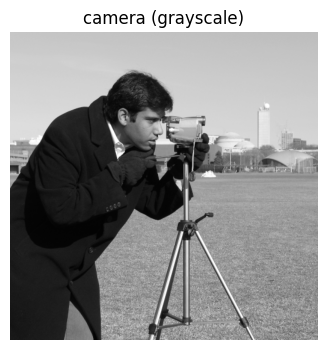

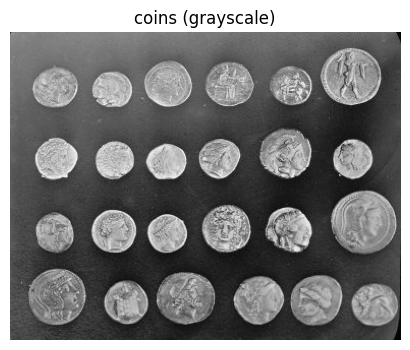

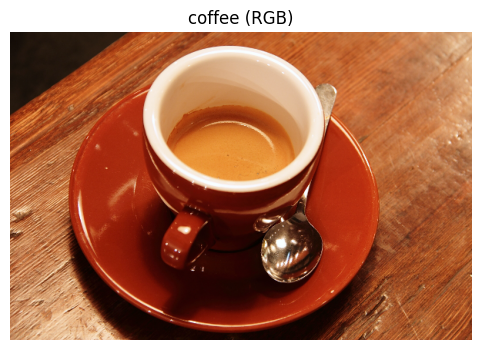

camera: (512, 512), dtype=uint8
coins:  (303, 384), dtype=uint8
coffee: (400, 600, 3), dtype=uint8


In [ ]:

cam = data.camera()                  # grayscale uint8
coins = data.coins()                 # grayscale uint8
coffee = data.coffee()               # RGB uint8

show(cam, "camera (grayscale)")
show(coins, "coins (grayscale)")
show(coffee, "coffee (RGB)", cmap=None)

print(f"camera: {cam.shape}, dtype={cam.dtype}")
print(f"coins:  {coins.shape}, dtype={coins.dtype}")
print(f"coffee: {coffee.shape}, dtype={coffee.dtype}")



---
## 1) Thresholding (Global / Otsu / Adaptive)

**Idea:** Pick intensity cutoffs to separate foreground from background.  
- **Global:** One threshold for the whole image (e.g., manual or Otsu).  
- **Adaptive (local):** Different threshold per neighborhood — helps under varying illumination.

> Sensitive to noise and contrast changes. Good as a baseline for simple, well-lit scenes.


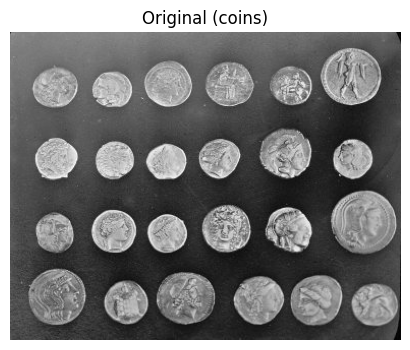

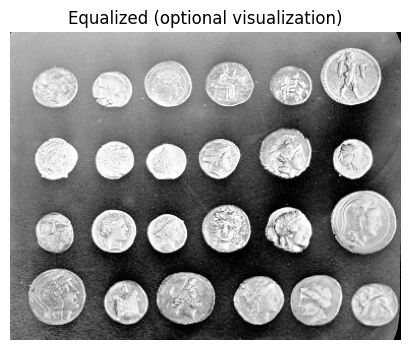

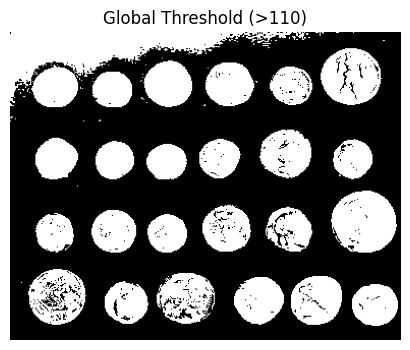

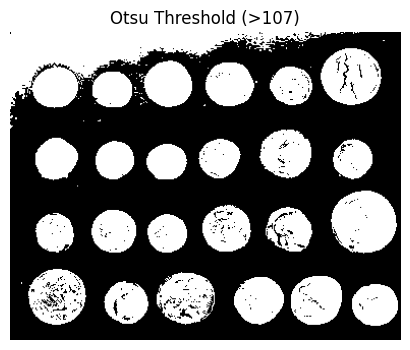

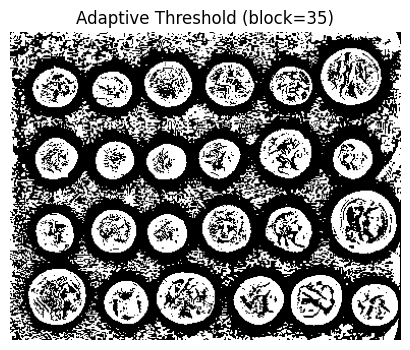

In [ ]:

img = coins
# Histogram equalization to improve contrast (optional)
img_eq = exposure.equalize_hist(img)

# Global manual threshold (example: 110 on uint8 scale)
global_thresh_val = 110
binary_global = img > global_thresh_val

# Otsu's method (automatic)
otsu_val = threshold_otsu(img)
binary_otsu = img > otsu_val

# Adaptive threshold (local mean)
block_size = 35  # odd number
adaptive_thresh = threshold_local(img, block_size=block_size, offset=0)
binary_adapt = img > adaptive_thresh

show(img, "Original (coins)")
show(img_eq, "Equalized (optional visualization)")
show(binary_global, f"Global Threshold (>{global_thresh_val})")
show(binary_otsu, f"Otsu Threshold (>{otsu_val})")
show(binary_adapt, f"Adaptive Threshold (block={block_size})")


### Exercise 1: Try Different Thresholds
- Change `global_thresh_val` (e.g., 80, 130) and observe results.
- Change `block_size` and `offset` for adaptive thresholding.
- Which method best separates the coins? Why?



---
## 2) Edge-Based Segmentation (Sobel, Canny)

**Idea:** Detect boundaries; edges can help you outline objects but don't fill interiors.  
- **Sobel:** Gradient magnitude; simple and fast.  
- **Canny:** Multi-stage detector with smoothing + hysteresis; good edges with fewer false positives.

> Often used as a **preprocessing** step or to create markers for region-based methods.


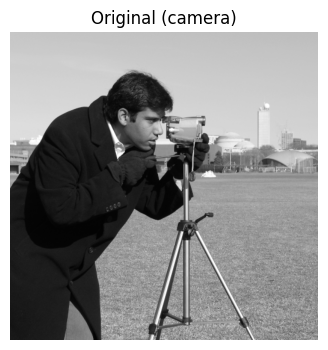

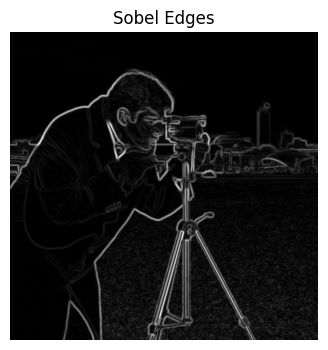

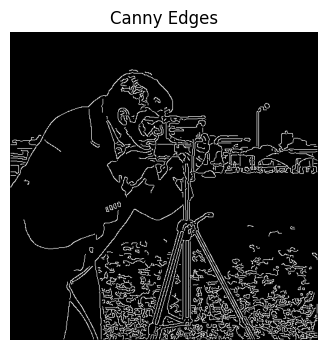

In [ ]:

img = cam
img_blur = filters.gaussian(img, sigma=1.0)

edges_sobel = filters.sobel(img_blur)
edges_canny = canny(img, sigma=1.2)  # sigma controls smoothing before edge detection

show(img, "Original (camera)")
show(edges_sobel, "Sobel Edges")
show(edges_canny, "Canny Edges")



### Exercise 2: Tuning Canny
- Play with `sigma` (e.g., 0.8, 1.5, 2.0).
- Observe how noise and detail affect the edge map.


---
## 3) Region-Based Segmentation with Watershed (Markers)

**Idea:** Think of the image as a topographic surface. Water floods from **markers** and fills basins until boundaries meet at ridges → **segments**.

**Procedure we'll use:**
1. Smooth & compute a **distance transform** on a binary mask.
2. Find **markers** (e.g., local maxima).
3. Run **Watershed** to split touching objects (like coins).

> Watershed works best when you have good markers and a clean background/foreground separation.


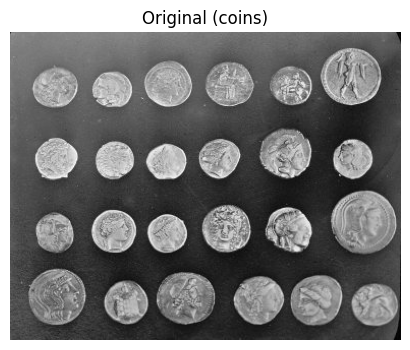

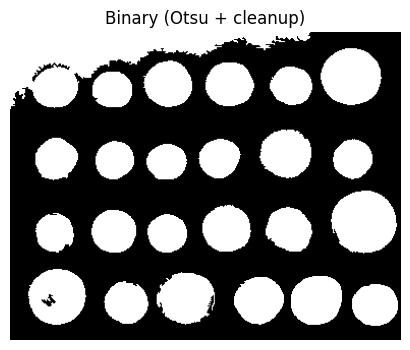

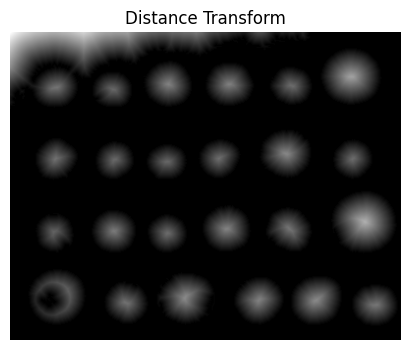

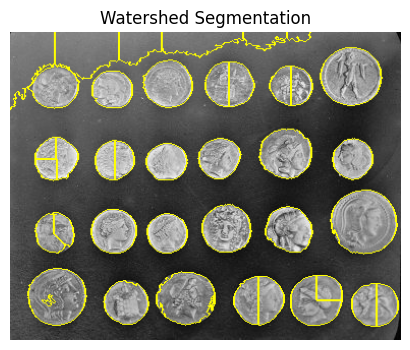

In [ ]:

img = coins

# 1) Get a decent binary mask (Otsu)
th = threshold_otsu(img)
bw = img > th

# Clean up small noise
bw = remove_small_objects(bw, min_size=64)
bw = remove_small_holes(bw, area_threshold=64)

# 2) Distance transform on foreground
distance = ndi.distance_transform_edt(bw)

# 3) Find local maxima as markers
local_max = feature.peak_local_max(
    distance, footprint=np.ones((25, 25)), labels=bw, exclude_border=False
)
markers = np.zeros_like(img, dtype=int)
for i, (r, c) in enumerate(local_max, start=1):
    markers[r, c] = i

# If no peaks are found (edge case), use connected components on bw
if markers.max() == 0:
    markers, _ = ndi.label(bw)

# 4) Watershed on the negative distance (so peaks are basins)
labels_ws = watershed(-distance, markers, mask=bw)

# Visualization
show(img, "Original (coins)")
show(bw, "Binary (Otsu + cleanup)")
show(distance, "Distance Transform")
show(segmentation.mark_boundaries(color.gray2rgb(img), labels_ws), "Watershed Segmentation")



### Exercise 3: Better Markers, Better Segments
- Change the `footprint` size in `peak_local_max` to merge/split markers.
- Try morphological operations (e.g., `morphology.closing`, `opening`) before watershed.
- Bonus: Use edges (Canny) as constraints for watershed (e.g., mask out edges).



---
## 4) Clustering-Based Segmentation (K-Means in Color Space)

**Idea:** Group pixels by color similarity (e.g., in RGB or Lab).  
- Choose a number of clusters `K` (e.g., 2–6).
- Cluster pixel colors; reshape labels back to the image.

> K-Means ignores spatial structure; results may be noisy (can be improved with smoothing or superpixels).


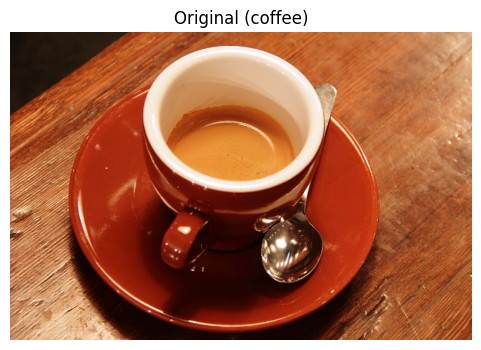

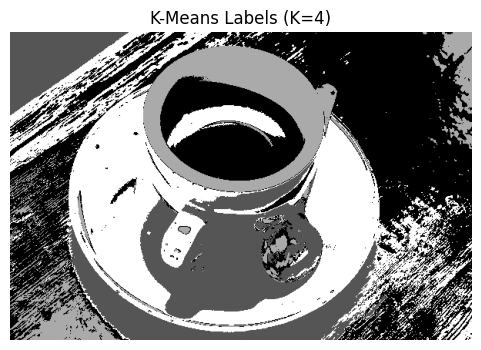

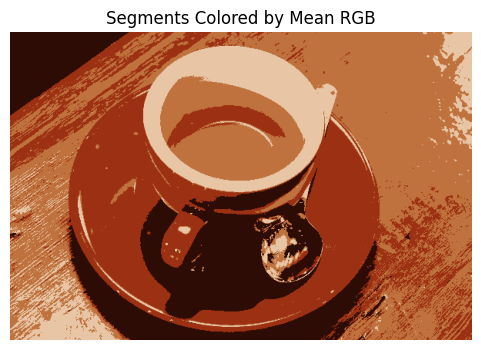

In [ ]:

img_rgb = coffee
img_lab = color.rgb2lab(img_rgb)  # perceptually meaningful space

H, W, C = img_lab.shape
X = img_lab.reshape(-1, C)

K = 4  # try 3, 5, etc.

if _HAVE_SKLEARN:
    kmeans = KMeans(n_clusters=K, n_init=5, random_state=0)
    labels = kmeans.fit_predict(X)
else:
    # Simple fallback K-Means (few iterations)
    rng = np.random.default_rng(0)
    centers = X[rng.choice(len(X), size=K, replace=False)]
    for _ in range(10):
        # Assign
        d2 = ((X[:, None, :] - centers[None, :, :])**2).sum(axis=2)
        labels = d2.argmin(axis=1)
        # Update
        for k in range(K):
            pts = X[labels == k]
            if len(pts) > 0:
                centers[k] = pts.mean(axis=0)

labels_img = labels.reshape(H, W)
# Color the segments by their mean RGB for a pretty visualization
seg_rgb = np.zeros_like(img_rgb, dtype=float)
for k in range(K):
    mask = labels_img == k
    seg_rgb[mask] = img_rgb[mask].mean(axis=0) / 255.0

show(img_rgb, "Original (coffee)", cmap=None)
show(labels_img, f"K-Means Labels (K={K})")
show(seg_rgb, "Segments Colored by Mean RGB", cmap=None)



### Exercise 4: K Selection & Spaces
- Try `K = 2, 3, 5, 6`. Which yields meaningful regions?
- Try clustering in **RGB** vs **Lab** (swap `img_lab` to `img_rgb` and scale to `[0,1]`).
- (Optional) Denoise before clustering: `filters.gaussian(img_rgb, sigma=1)`. Does it help?



---
## Mini-Project: Segment Coins (End-to-End)

**Task:** Build a simple pipeline that counts individual coins using **thresholding + distance transform + watershed**.

**Steps to implement (starter below):**
1. Preprocess (denoise slightly).
2. Threshold (try Otsu).
3. Morphological cleanup (remove small artifacts; fill small holes).
4. Distance transform → markers.
5. Watershed → labeled instances.
6. Compute object **count** and **areas**; visualize boundaries.

> Deliverable: print the number of coins and plot labeled segments with random colors.


Estimated coin count: {len(regions)}
Area stats: min={np.min(areas) if areas else 0}, median={np.median(areas) if areas else 0}, max={np.max(areas) if areas else 0}


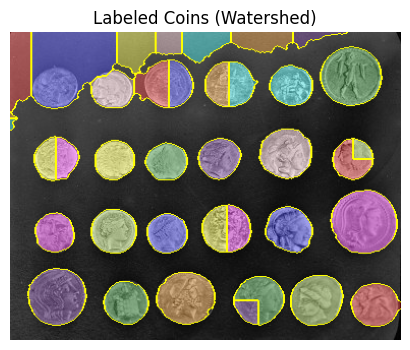

In [ ]:

# --- Starter Pipeline ---
img = coins

# 1) Denoise gently
img_f = filters.gaussian(img, sigma=0.8)

# 2) Threshold (Otsu)
th = threshold_otsu(img_f)
bw = img_f > th

# 3) Morphological cleanup
bw = morphology.closing(bw, footprint=disk(3))
bw = remove_small_objects(bw, min_size=64)
bw = remove_small_holes(bw, area_threshold=64)

# 4) Distance + markers
distance = ndi.distance_transform_edt(bw)
local_max = feature.peak_local_max(distance, footprint=np.ones((21,21)), labels=bw, exclude_border=False)
markers = np.zeros_like(img, dtype=int)
for i, (r, c) in enumerate(local_max, start=1):
    markers[r, c] = i
if markers.max() == 0:
    markers, _ = ndi.label(bw)

# 5) Watershed
labels_ws = watershed(-distance, markers, mask=bw)

# 6) Measurements
regions = measure.regionprops(labels_ws)
areas = [r.area for r in regions]
print("Estimated coin count: {len(regions)}")
print("Area stats: min={np.min(areas) if areas else 0}, median={np.median(areas) if areas else 0}, max={np.max(areas) if areas else 0}")

# Visualization: label overlay
label_overlay = color.label2rgb(labels_ws, image=img, bg_label=0, alpha=0.3, kind='overlay')
show(segmentation.mark_boundaries(label_overlay, labels_ws), "Labeled Coins (Watershed)")



---
##  When Do Classic Methods Struggle?

- **Lighting variations** → Adaptive thresholding helps, but not always.
- **Low contrast / noise** → Edges break; regions merge; K-Means is unstable.
- **Texture & shape ambiguity** → No notion of semantics (e.g., distinguishing "road" vs. "building").
- **Touching instances** → Need careful markers for Watershed.

> This motivates **deep learning** (U-Net) which learns **features** and **context** from data.  
In the next practical, you'll implement **Binary Segmentation with U-Net** and compare it against these methods.



---
## What Next
- In the next practical, we'll implement **Binary Image Segmentation with U-Net** and compare against these baselines.



---
📝 This practical was designed to give you a concise, hands-on introduction to **classic image segmentation** (traditional CV techniques).